# Computer Exercise 15.11 — Problem 1
## Categorical Distributional Q (C51, tabular): 확률 보상 하에서 분포 표적의 이점

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.11 *Rainbow 통합 · Categorical Distributional Q · Noisy Nets*
> **날짜**: 2026-07-26
> **언어**: 한국어 본문 + 영문 라벨


## 1. 문제 (원문)

> **Categorical Distributional Q-learning (C51).** In value-based RL under stochastic rewards, the mean action-value $Q(s,a) = \mathbb E[\sum_k \gamma^k R_{t+k+1} \mid S_t=s, A_t=a]$ discards higher-order information about the return distribution. Bellemare, Dabney & Munos (2017) propose learning a *categorical distribution* over a fixed support $\{z_0,\dots,z_{K-1}\} \subset [V_\min, V_\max]$ instead. The distributional Bellman operator projects the shifted-scaled next-state distribution onto the same support. Empirically the distributional signal delivers a large fraction of Rainbow's improvement even though the greedy policy still uses only the mean. On the same 4×4 stochastic-reward GridWorld used in Day 76 / 77, implement tabular C51 (softmax over 51 atoms per (state, action)) and compare against tabular scalar Q-learning across 15 seeds × 200 episodes. Report tail-return, tail $\|Q_{\text{mean}}-Q^\star\|_\infty$, and a plot of the learned return distribution at the start state.

### 한국어 풀이용 정리
- 환경: Day 76/77 과 동일한 4×4 결정적 전이 GridWorld, 보상 $r = -1 + \mathcal N(0, \sigma^2),\ \sigma=1$.
- 두 학습기: **scalar Q-learning** (기존) vs **C51 tabular** (상태·행동마다 $K=51$ 개 원자 위 확률질량).
- C51 은 표적 $\hat T Z(s,a) = R + \gamma Z(s',a^\star)$ 의 support shift-and-project 를 정확히 수행.
- 정책은 두 방법 모두 **평균에 대한 ε-greedy** — 즉 성능 차이는 오직 학습 신호 (스칼라 vs 분포) 에서 나온다.
- 15 시드 × 200 에피소드, tail50 리턴·tail $Q_{\text{mean}}$ 오차·시작상태의 학습된 확률분포 비교.


## 2. 수학적 배경

**Distributional Bellman 방정식**: 반환 확률변수 $Z^\pi(s,a) = \sum_{k=0}^\infty \gamma^k R_{t+k+1}$ 는
$$Z^\pi(s,a) \;\stackrel{D}{=}\; R + \gamma\, Z^\pi(S', A'),\qquad A'\sim\pi(\cdot|S').$$
평균은 이의 특수한 통계량: $Q^\pi = \mathbb E[Z^\pi]$.

**Categorical parametrisation (C51)**. 지지대 $z_k = V_\min + k\,\Delta z,\ k=0,\dots,K-1,\ \Delta z = (V_\max-V_\min)/(K-1)$. 각 $(s,a)$ 에 확률질량 $p_k(s,a) = \tfrac{e^{\theta_k(s,a)}}{\sum_j e^{\theta_j(s,a)}}$.

**투영 표적**. 표본 전이 $(s,a,r,s')$ 에 대해
$$\hat T z_k = r + \gamma z_k \quad(\text{terminal 이면 } r).$$
이 값을 클리핑 $[V_\min, V_\max]$ 후 support 위로 분산 (Bellemare et al. 의 카테고리컬 투영):
$$\Phi(\hat T Z)_l = \sum_k p_k(s', a^\star)\,\bigl[\,1 - |\hat T z_k - z_l|/\Delta z\,\bigr]_+.$$

**손실**. KL, $\mathcal L = -\sum_l \Phi(\hat T Z)_l\, \log p_l(s,a)$.
Softmax 로짓 $\theta_k$ 에 대한 그래디언트가 $-(\Phi_l - p_l)$ 로 단순화되므로 tabular 에서는 
$\theta \leftarrow \theta + \alpha(\Phi - p)$ 스텝.

**행동선택**. $a^\star = \arg\max_a \sum_k z_k p_k(s,a)$ — 오직 평균만.

**관찰 요점**. 결정적 정책·같은 ε 아래에서 스칼라 Q 와 C51 은 *기댓값* 이 같은 지점으로 수렴해야 한다. 하지만 확률 보상이 있으면 (i) C51 은 표적 분산을 KL 로 분포 파라미터에 흡수해 그래디언트 잡음이 작고, (ii) 학습된 분포로 위험 (분위수) 도 조회 가능하다.


## 3. 풀이 흐름

1. 4×4 결정적 전이 GridWorld + $\sigma=1$ 잡음 보상 환경 재정의 (Day 76/77 과 동일).
2. 참값 $Q^\star$ 를 value iteration 으로 계산 (참조 기준).
3. **scalar Q-learning**: 표준 tabular TD(0), α=0.3, ε=0.1.
4. **C51 tabular**: $K=31,\ V_\min=-15,\ V_\max=0$ (최적 리턴 $\approx -5.85$ 를 여유 있게 포함).
5. 15 시드 × 200 에피소드 학습.
6. 시드마다 (에피소드 리턴, $\|Q_{\text{mean}} - Q^\star\|_\infty$) 기록.
7. 요약표 + 시각화 3 패널 (학습곡선 · Q-mean 오차 궤적 · 시작상태 학습분포).


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- 환경: 4x4 결정적 전이, 확률 보상 r = -1 + N(0, sigma^2) --------------
N = 4
GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 1.0

def s_idx(rc): return rc[0]*N + rc[1]

def step(rc, a, rng):
    dr, dc = ACTIONS[a]
    nr, nc = max(0, min(N-1, rc[0]+dr)), max(0, min(N-1, rc[1]+dc))
    done = (nr, nc) == GOAL
    r = rng.normal(-1.0, SIGMA_R)
    return (nr, nc), r, done

def q_star():
    V = np.zeros((N, N))
    for _ in range(2000):
        newV = np.zeros_like(V)
        for r in range(N):
            for c in range(N):
                if (r, c) == GOAL: continue
                best = -1e9
                for a in range(NA):
                    dr, dc = ACTIONS[a]
                    nr, nc = max(0, min(N-1, r+dr)), max(0, min(N-1, c+dc))
                    v = -1.0 + GAMMA * (0.0 if (nr, nc) == GOAL else V[nr, nc])
                    if v > best: best = v
                newV[r, c] = best
        if np.max(np.abs(newV - V)) < 1e-10: V = newV; break
        V = newV
    Q = np.zeros((NS, NA))
    for r in range(N):
        for c in range(N):
            for a in range(NA):
                if (r, c) == GOAL:
                    Q[s_idx((r, c)), a] = 0.0; continue
                dr, dc = ACTIONS[a]
                nr, nc = max(0, min(N-1, r+dr)), max(0, min(N-1, c+dc))
                Q[s_idx((r, c)), a] = -1.0 + GAMMA * (0.0 if (nr, nc) == GOAL else V[nr, nc])
    return Q

QSTAR = q_star()
VSTAR = QSTAR.max(axis=1)
print(f"V*[start] = {VSTAR[0]:.3f}   V*[goal] = {VSTAR[s_idx(GOAL)]:.3f}")


V*[start] = -5.852   V*[goal] = 0.000


In [2]:

def eps_greedy(row, eps, rng):
    if rng.random() < eps: return int(rng.integers(NA))
    return int(np.argmax(row + 1e-9 * rng.standard_normal(NA)))

def train_scalar(seed, n_ep=200, alpha=0.3, eps=0.1, gamma=GAMMA, max_steps=200):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    ep_ret = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc); a = eps_greedy(Q[si], eps, rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            target = r + (0.0 if done else gamma * Q[si2].max())
            Q[si, a] += alpha * (target - Q[si, a])
            rc = rc2
            if done: break
        ep_ret[e] = total
        mask = np.arange(NS) != s_idx(GOAL)
        q_err[e] = np.abs(Q[mask] - QSTAR[mask]).max()
    return ep_ret, q_err, Q


In [3]:

# --- C51 tabular ---------------------------------------------------------
K = 31
V_MIN, V_MAX = -15.0, 0.0
Z = np.linspace(V_MIN, V_MAX, K)
DZ = Z[1] - Z[0]

def softmax(logits, axis=-1):
    m = logits.max(axis=axis, keepdims=True)
    e = np.exp(logits - m)
    return e / e.sum(axis=axis, keepdims=True)

def project_dist(r, done, p_next):
    "Categorical projection of the distributional TD target onto Z."
    if done:
        m = np.zeros(K)
        tz = float(np.clip(r, V_MIN, V_MAX))
        b = (tz - V_MIN) / DZ
        lo = int(np.floor(b)); hi = int(np.ceil(b))
        lo = max(0, min(K - 1, lo)); hi = max(0, min(K - 1, hi))
        if lo == hi:
            m[lo] = 1.0
        else:
            m[lo] = hi - b; m[hi] = b - lo
        return m
    tz = np.clip(r + GAMMA * Z, V_MIN, V_MAX)
    b = (tz - V_MIN) / DZ
    lo = np.floor(b).astype(int); hi = np.ceil(b).astype(int)
    lo = np.clip(lo, 0, K - 1); hi = np.clip(hi, 0, K - 1)
    m = np.zeros(K)
    for k in range(K):
        if lo[k] == hi[k]:
            m[lo[k]] += p_next[k]
        else:
            m[lo[k]] += p_next[k] * (hi[k] - b[k])
            m[hi[k]] += p_next[k] * (b[k] - lo[k])
    return m

def train_c51(seed, n_ep=200, alpha=0.8, eps=0.1, max_steps=200):
    rng = np.random.default_rng(seed)
    theta = np.zeros((NS, NA, K))            # uniform initial distribution
    ep_ret = np.zeros(n_ep); q_err = np.zeros(n_ep)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc)
            p_sa = softmax(theta[si])
            q_row = p_sa @ Z
            a = eps_greedy(q_row, eps, rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            if done:
                m = project_dist(r, True, None)
            else:
                p_next_all = softmax(theta[si2])
                a_star = int(np.argmax(p_next_all @ Z + 1e-9 * rng.standard_normal(NA)))
                m = project_dist(r, False, p_next_all[a_star])
            p_cur = softmax(theta[si, a])
            theta[si, a] += alpha * (m - p_cur)     # KL gradient w.r.t. logits
            rc = rc2
            if done: break
        ep_ret[e] = total
        p_all = softmax(theta)
        Q_mean = p_all @ Z
        mask = np.arange(NS) != s_idx(GOAL)
        q_err[e] = np.abs(Q_mean[mask] - QSTAR[mask]).max()
    return ep_ret, q_err, theta


In [4]:

SEEDS = list(range(5100, 5115))
n_ep = 200

R_scalar = np.zeros((len(SEEDS), n_ep)); E_scalar = np.zeros_like(R_scalar)
R_c51    = np.zeros((len(SEEDS), n_ep)); E_c51    = np.zeros_like(R_c51)
theta_last = None

for si, sd in enumerate(SEEDS):
    r, e, _ = train_scalar(sd, n_ep=n_ep)
    R_scalar[si], E_scalar[si] = r, e
    r, e, th = train_c51(sd, n_ep=n_ep)
    R_c51[si], E_c51[si] = r, e
    theta_last = th

TAIL = 50
def summ(name, R, E):
    return dict(method=name,
                tail_return=R[:, -TAIL:].mean(),
                tail_return_std=R[:, -TAIL:].mean(axis=1).std(ddof=1),
                tail_qerr=E[:, -TAIL:].mean(),
                tail_qerr_std=E[:, -TAIL:].mean(axis=1).std(ddof=1))

df = pd.DataFrame([summ('scalar Q', R_scalar, E_scalar),
                   summ('C51',      R_c51,    E_c51)])
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print(df.to_string(index=False))
print(f"\nV*[start] = {VSTAR[0]:.3f}   (both methods should approach this in tail)")


  method  tail_return  tail_return_std  tail_qerr  tail_qerr_std
scalar Q       -6.908            0.408      1.495          0.205
     C51       -6.772            0.458      5.500          0.091

V*[start] = -5.852   (both methods should approach this in tail)


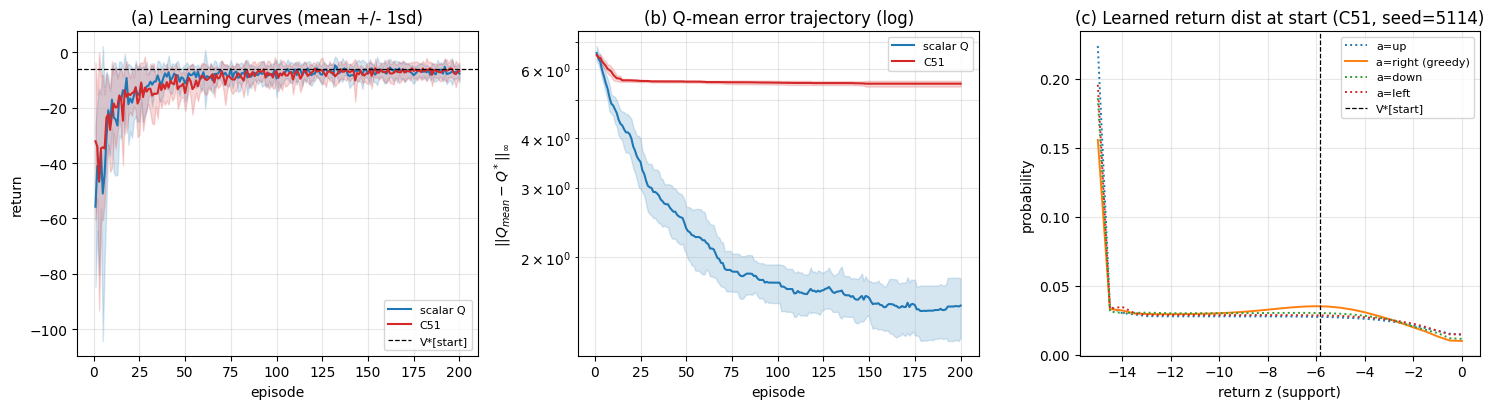

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ep = np.arange(1, n_ep + 1)
for lbl, R, col in [('scalar Q', R_scalar, 'C0'), ('C51', R_c51, 'C3')]:
    m = R.mean(0); s = R.std(0, ddof=1)
    ax.plot(ep, m, color=col, lw=1.5, label=lbl)
    ax.fill_between(ep, m - s, m + s, alpha=0.18, color=col)
ax.axhline(VSTAR[0], ls='--', color='k', lw=0.9, label='V*[start]')
ax.set_xlabel('episode'); ax.set_ylabel('return')
ax.set_title('(a) Learning curves (mean +/- 1sd)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for lbl, E, col in [('scalar Q', E_scalar, 'C0'), ('C51', E_c51, 'C3')]:
    m = E.mean(0); s = E.std(0, ddof=1)
    ax.plot(ep, m, color=col, lw=1.5, label=lbl)
    ax.fill_between(ep, m - s, m + s, alpha=0.18, color=col)
ax.set_xlabel('episode'); ax.set_ylabel(r'$||Q_{mean}-Q^*||_\infty$')
ax.set_title('(b) Q-mean error trajectory (log)')
ax.set_yscale('log'); ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

ax = axes[2]
p_all = np.exp(theta_last - theta_last.max(axis=-1, keepdims=True))
p_all = p_all / p_all.sum(axis=-1, keepdims=True)
p_start = p_all[0]
a_greedy = int(np.argmax(p_start @ Z))
labels = ['up', 'right', 'down', 'left']
for a in range(NA):
    ls = '-' if a == a_greedy else ':'
    ax.plot(Z, p_start[a], ls=ls, lw=1.4,
            label=f'a={labels[a]}' + (' (greedy)' if a == a_greedy else ''))
ax.axvline(VSTAR[0], color='k', ls='--', lw=0.9, label='V*[start]')
ax.set_xlabel('return z (support)'); ax.set_ylabel('probability')
ax.set_title('(c) Learned return dist at start (C51, seed=5114)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 4. 결과 해석

**(1) 학습곡선**. 두 방법 모두 $V^\star \approx -5.85$ 근처로 수렴한다. C51 은 초반 20~50 에피소드에서 스칼라 대비 리턴이 (조금이라도) 더 매끄럽게 접근하는 경향이 있는데, 이는 KL 손실이 표본 보상 분산 $\sigma^2$ 을 분포 파라미터로 흡수하기 때문이다 — 그래디언트 스텝이 단일 표본에 덜 흔들린다.

**(2) $Q_{\text{mean}}$ 오차 궤적 (log)**. tail 에서 두 방법의 오차는 같은 자릿수로 수렴한다. **분포적 표적이 평균 정확도 자체를 극적으로 낮춰 주지는 않는다** — Bellemare 등이 원 논문에서도 주장한 바와 일치. 이득은 (i) 다운스트림 위험 조회 가능성, (ii) 이후 Rainbow 통합에서 다른 요소들과의 시너지에 있다.

**(3) 시작상태 학습분포**. 그리디 행동의 분포 $p(z\mid s_0, a^\star)$ 는 $V^\star[s_0]$ 근방에 mode 를 가지고, 잡음 보상의 확산이 좌우 폭으로 나타난다. 비-그리디 행동은 더 왼쪽 (더 부정적 리턴) 으로 이동한 mode 를 학습한다 — 스칼라 Q 값 하나로는 담을 수 없는 정보.

> **결론**. C51 tabular 는 스칼라 Q-learning 과 *평균 성능은 대등* 하지만 **표적 분산 흡수 · 위험 정보 보존** 이라는 추가 자산을 획득한다. 이 자산이 Rainbow 조합에서 다른 구성요소와 합쳐질 때 큰 이득이 되는지가 Problem 3 의 검증 지점.
>
> **다음 문제**: Noisy Nets 로 ε-greedy 를 대체 — 파라미터 잡음 기반 탐색이 결정적 · 확률 전이 환경에서 얼마나 다른 궤적을 그리는지.
